In [77]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:/Users/mishr/OneDrive/Desktop/DATA ANALYTICS/credit_risk_dataset_cleaned.csv"
)

# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

df.head()

,Customer_Age,Customer_income,Home_ownership,Employment_length,Purpose_of_loan,Loan_risk_grade,Loan_amount,Interest_rate,Loan_Status,Loan_amount_as_%_of_income,Previous_default_history,Credit_history_length,person_emp_length_clean,loan_int_rate_clean
0,20,64000,RENT,3.0,VENTURE,D,16000,15.31,1,0.25,Y,4,3,15.31
1,20,32652,MORTGAGE,0.0,PERSONAL,D,6000,14.61,1,0.18,N,4,0,14.61
2,20,94000,RENT,4.0,EDUCATION,D,5000,16.02,0,0.05,N,3,4,16.02
3,20,42000,RENT,4.0,VENTURE,B,6500,11.71,0,0.15,N,2,4,11.71
4,20,34800,RENT,3.0,MEDICAL,C,7000,13.61,0,0.20,Y,2,3,13.61


In [58]:
#1.What is the overall distribution of loan defaults and non-defaults?

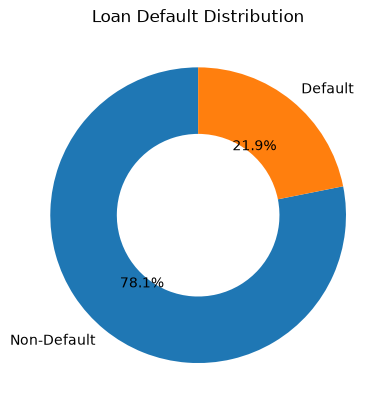

<Figure size 640x480 with 0 Axes>

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/mishr/OneDrive/Desktop/DATA ANALYTICS/credit_risk_dataset_cleaned.csv")
df.head()
df["Loan_Status"].value_counts()

plt.pie(counts, labels=["Non-Default", "Default"],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"width":0.45})

plt.title("Loan Default Distribution")
plt.show()
plt.savefig("Q1_Default_Distribution.png", dpi=300, bbox_inches="tight")

In [ ]:
#2.How does the default rate vary across different loan risk grades?

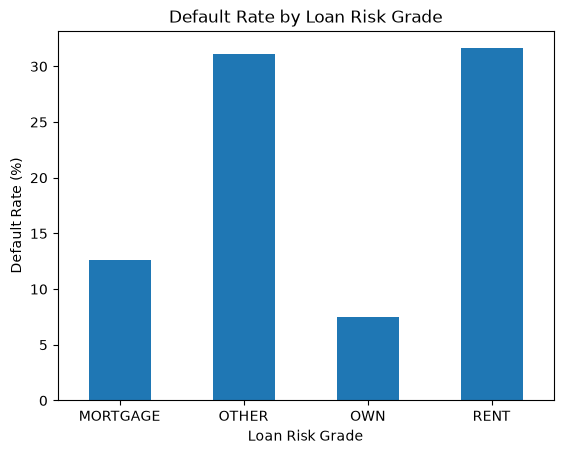

<Figure size 640x480 with 0 Axes>

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/mishr/OneDrive/Desktop/DATA ANALYTICS/credit_risk_dataset_cleaned.csv")
df.head()
default_by_grade = (df.groupby("Loan_risk_grade")["Loan_Status"]
      .mean()
      .mul(100)
      .reset_index(name="Default_Rate").round(2))
rate.plot(kind="bar")

plt.title("Default Rate by Loan Risk Grade")
plt.xlabel("Loan Risk Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()
plt.savefig("Q2_Default_Rate_by_Grade.png", dpi=300, bbox_inches="tight")

In [ ]:
#3.Which loan purpose has the highest number of defaults?

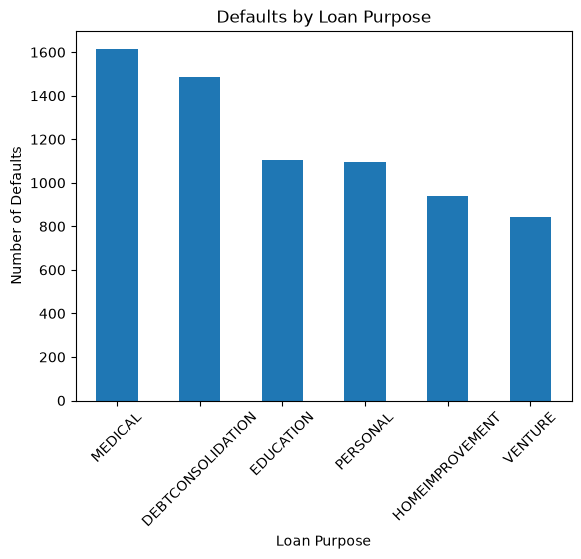

<Figure size 640x480 with 0 Axes>

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/mishr/OneDrive/Desktop/DATA ANALYTICS/credit_risk_dataset_cleaned.csv")
df.head()
default_by_purpose = df.groupby("Purpose_of_loan")["Loan_Status"].sum()
default_by_purpose = default_by_purpose.sort_values(ascending=False)

purpose.plot(kind="bar")

plt.title("Defaults by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Defaults")
plt.xticks(rotation=45)
plt.show()
plt.savefig("Q3_Defaults_by_Loan_Purpose.png", dpi=300, bbox_inches="tight")

In [ ]:
#4.How does customer income differ between defaulted and non-defaulted loans?

In [ ]:
#5.How does the average interest rate differ between defaulted and non-defaulted loans?

Loan_Status
0    10.44
1    13.07
Name: Interest_rate, dtype: float64


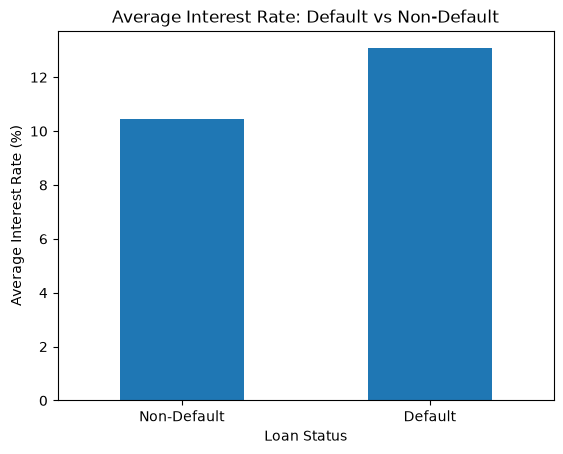

<Figure size 640x480 with 0 Axes>

In [89]:
import matplotlib.pyplot as plt

interest = df.groupby("Loan_Status")["Interest_rate"].mean()

print(interest.round(2))

interest.plot(kind="bar")

plt.title("Average Interest Rate: Default vs Non-Default")
plt.xlabel("Loan Status")
plt.ylabel("Average Interest Rate (%)")
plt.xticks([0, 1], ["Non-Default", "Default"], rotation=0)
plt.show()
plt.savefig("Q5_Average_Interest_Rate.png", dpi=300, bbox_inches="tight")

In [ ]:
#6.How does the average loan amount differ between defaulted and non-defaulted loans?

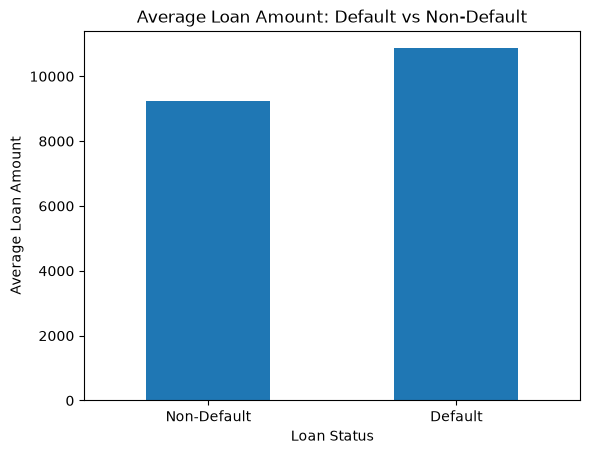

<Figure size 640x480 with 0 Axes>

In [95]:
df.columns = df.columns.str.strip()
import matplotlib.pyplot as plt

amount = df.groupby("Loan_Status")["Loan_amount"].mean().round(2)

amount.plot(kind="bar")

plt.title("Average Loan Amount: Default vs Non-Default")
plt.xlabel("Loan Status")
plt.ylabel("Average Loan Amount")
plt.xticks([0, 1], ["Non-Default", "Default"], rotation=0)
plt.show()
plt.savefig("Q6_Average_Loan_Amount.png", dpi=300, bbox_inches="tight")

In [ ]:
#7.How does the default rate change across different customer age groups?

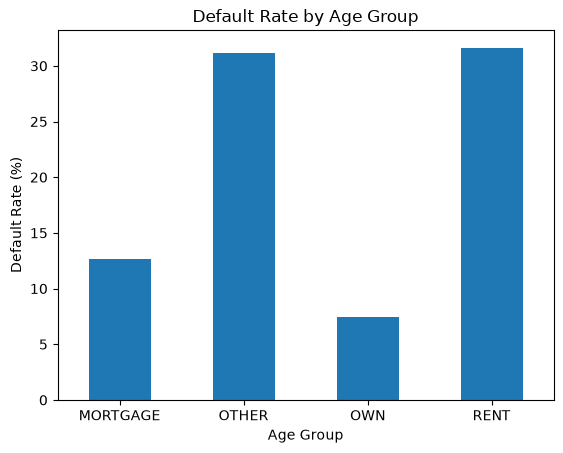

<Figure size 640x480 with 0 Axes>

In [96]:
df.columns = df.columns.str.strip()
import matplotlib.pyplot as plt
df["Age_Group"]=pd.cut(df["Customer_Age"],bins=[19,29,39,49,float("inf")],labels=["20-29","30-39","40-49","50+"])
default_by_age=(df.groupby("Age_Group",observed=True)["Loan_Status"].mean().mul(100).round(2))
default_by_age
rate.plot(kind="bar")

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()
plt.savefig("Q7_Default_Rate_by_Age_Group.png", dpi=300, bbox_inches="tight")

In [ ]:
#8.How does home ownership relate to loan defaults?

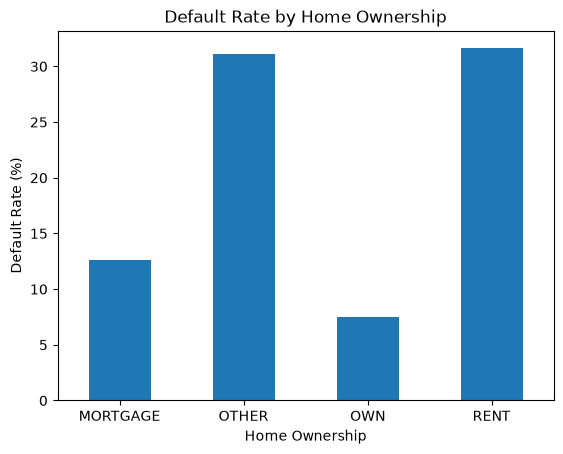

<Figure size 640x480 with 0 Axes>

In [97]:
import matplotlib.pyplot as plt
default_by_home=(df.groupby("Home_ownership")["Loan_Status"].mean().mul(100).round(2))
default_by_home
rate = df.groupby("Home_ownership")["Loan_Status"].mean() * 100

rate.plot(kind="bar")

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()
plt.savefig("Q8_Default_Rate_by_Home_Ownership.png", dpi=300, bbox_inches="tight")

In [ ]:
#9.Which numerical factors have the strongest relationship with loan default status?

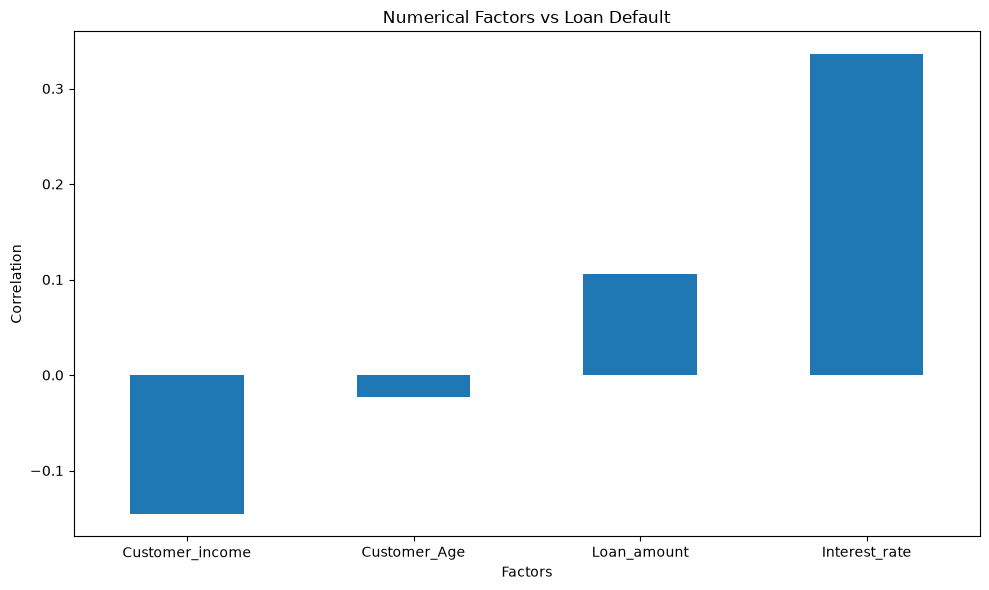

<Figure size 640x480 with 0 Axes>

In [98]:
import matplotlib.pyplot as plt

cols = ["Customer_Age", "Customer_income", "Loan_amount", "Interest_rate", "Loan_Status"]

corr = df[cols].corr()["Loan_Status"].drop("Loan_Status").sort_values()

plt.figure(figsize=(10, 6))
corr.plot(kind="bar")

plt.title("Numerical Factors vs Loan Default")
plt.xlabel("Factors")
plt.ylabel("Correlation")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()
plt.savefig("Q9_Numerical_Factors_vs_Default.png", dpi=300, bbox_inches="tight")

In [ ]:
#10.What are the key patterns in the dataset that may help explain loan default risk?

In [51]:
# 1. Default rate by loan risk grade
default_risk_grade=df.groupby("Loan_risk_grade")["Loan_Status"].mean().mul(100).round(2)
# 2. Default rate by home ownership
default_by_home=df.groupby("Home_ownership")["Loan_Status"].mean().mul(100).round(2)
# 3. Average income by loan status
income_by_status=df.groupby("Loan_Status")["Customer_income"].mean().round(2)
# 4. Average interest rate by loan status
interest_by_status=df.groupby("Loan_Status")["Interest_rate"].mean().round(2)
# 5. Average loan amount by loan status
loan_amount_by_status=df.groupby("Loan_Status")["Loan_amount"].mean().round(2)
print("Default rate by loan risk grade:")
print(default_risk_grade)

print("Default rate by home ownership:")
print(default_by_home)

print("Average income by home ownership:")
print(income_by_status)

print("Average interest rate by loan status:")
print(interest_by_status)

print("Average loan amount by loan status:")
print(loan_amount_by_status)

Default rate by loan risk grade:
Loan_risk_grade
A     9.96
B    16.33
C    20.75
D    59.06
E    64.49
F    70.54
G    98.44
Name: Loan_Status, dtype: float64
Default rate by home ownership:
Home_ownership
MORTGAGE    12.62
OTHER       31.13
OWN          7.49
RENT        31.61
Name: Loan_Status, dtype: float64
Average income by home ownership:
Loan_Status
0    70850.82
1    49091.97
Name: Customer_income, dtype: float64
Average interest rate by loan status:
Loan_Status
0    10.44
1    13.07
Name: Interest_rate, dtype: float64
Average loan amount by loan status:
Loan_Status
0     9240.38
1    10857.64
Name: Loan_amount, dtype: float64


In [54]:
df.to_csv("credit_risk_final.csv", index=False)

In [55]:
import os

os.getcwd()

'C:\\Users\\mishr'

In [56]:
os.listdir()

['.anaconda',
 '.android',
 '.bash_history',
 '.conda',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.virtual_documents',
 'anaconda3',
 'AppData',
 'Apple',
 'Application Data',
 'bar.png',
 'boxplot.png',
 'Contacts',
 'Cookies',
 'credit_risk_final.csv',
 'Data Frame.ipynb',
 'Documents',
 'Downloads',
 'Favorites',
 'hist.png',
 'hotel_bookings.csv',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'mishra',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{c5c3a441-b31d-11ef-990b-9f17f9efa2e9}.TM.blf',
 'NTUSER.DAT{c5c3a441-b31d-11ef-990b-9f17f9efa2e9}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{c5c3a441-b31d-11ef-990b-9f17f9efa2e9}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PDFEditor',
 'plot.png',
 'Portfolio Project 1.ipynb',
 'PrintHood',
 'PyCharm 2026.1.4',
 'PycharmProjects',
 'Recent',
 'rohitk',
 'Saved Games',
 'Seaborn.ipynb',
